In [1]:
# === IMPORTS ===
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss, mean_absolute_error, mean_squared_error, cohen_kappa_score, hamming_loss, roc_curve, auc
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-10-28 15:43:05.436496: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761666185.925524      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761666186.050529      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# === CONFIGURATION ===
data_folder = "/kaggle/input/dataset2/archive_5"
tumor_types = ["no", "yes"]
IMG_SIZE = 150

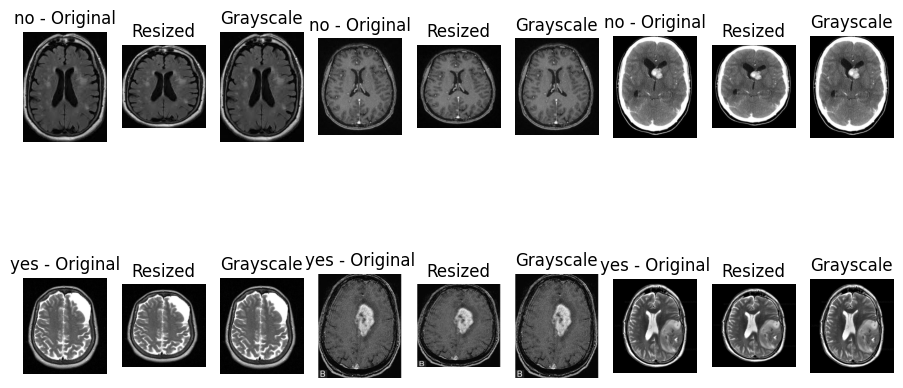

In [3]:
# === VISUALIZATION FUNCTION ===
def visualize_sample_images(folder, tumor_types, IMG_SIZE, samples_per_class=3):
    classes = len(tumor_types)
    plt.figure(figsize=(samples_per_class * 3, classes * 3))

    for i, tumor_type_idx in enumerate(range(1, classes + 1)):
        tumor_folder = os.path.join(folder, str(tumor_type_idx))
        images_displayed = 0
        for filename in os.listdir(tumor_folder):
            if images_displayed >= samples_per_class:
                break
            img_path = os.path.join(tumor_folder, filename)
            try:
                img_orig = Image.open(img_path).convert('L')
                img_resized = img_orig.resize((IMG_SIZE, IMG_SIZE))
                img_gray = img_orig.convert('L')

                plt.subplot(classes, samples_per_class * 3, i * samples_per_class * 3 + images_displayed * 3 + 1)
                plt.imshow(img_orig, cmap='gray')
                plt.title(f"{tumor_types[i]} - Original")
                plt.axis('off')

                plt.subplot(classes, samples_per_class * 3, i * samples_per_class * 3 + images_displayed * 3 + 2)
                plt.imshow(img_resized, cmap='gray')
                plt.title("Resized")
                plt.axis('off')

                plt.subplot(classes, samples_per_class * 3, i * samples_per_class * 3 + images_displayed * 3 + 3)
                plt.imshow(img_gray, cmap='gray')
                plt.title("Grayscale")
                plt.axis('off')

                images_displayed += 1
            except:
                continue
    plt.tight_layout()
    plt.show()

visualize_sample_images(data_folder, tumor_types, IMG_SIZE)

In [4]:
# === LOAD IMAGES ===
def load_images_from_folder(folder):
    images, labels = [], []
    for tumor_type_idx, tumor_type in enumerate(tumor_types, start=1):
        tumor_folder = os.path.join(folder, str(tumor_type_idx))
        for filename in os.listdir(tumor_folder):
            img_path = os.path.join(tumor_folder, filename)
            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                img = np.array(img)
                img = cv2.equalizeHist(img)
                img = np.expand_dims(img, axis=-1)
                images.append(img)
                labels.append(tumor_type)
            except:
                continue
    return np.array(images), np.array(labels)

images, labels = load_images_from_folder(data_folder)
images = images.astype("float32") / 255.0


In [5]:
# === LABEL ENCODING ===
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_cat = to_categorical(labels_encoded)

In [6]:
# === TRAIN-TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(images, labels_cat, test_size=0.2, stratify=labels_cat, random_state=42)


In [7]:
# === AUGMENTATION ===
datagen = ImageDataGenerator(rotation_range=20, zoom_range=0.15, width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
datagen.fit(X_train)
X_train_new, X_val, y_train_new, y_val = train_test_split(X_train, y_train, test_size=0.1, stratify=y_train, random_state=42)
train_gen = datagen.flow(X_train_new, y_train_new, batch_size=32)
val_gen = datagen.flow(X_val, y_val, batch_size=32)


In [8]:
# === MODEL DEFINITIONS CNN ===
def build_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [9]:
# === MODEL DEFINITIONS build_alexnet ===
def build_alexnet(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(96, (11,11), strides=(4,4), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2)),
        tf.keras.layers.Conv2D(256, (5,5), padding="same", activation='relu'),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2)),
        tf.keras.layers.Conv2D(384, (3,3), padding="same", activation='relu'),
        tf.keras.layers.Conv2D(384, (3,3), padding="same", activation='relu'),
        tf.keras.layers.Conv2D(256, (3,3), padding="same", activation='relu'),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [10]:
# === MODEL DEFINITIONS build_vgg16 ===
def build_vgg16(input_shape, num_classes):
    base_model = tf.keras.applications.VGG16(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(3, (3,3), padding='same', input_shape=input_shape),
        base_model,
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [11]:
# === GAN MODELS ===
def build_generator():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128 * 38 * 38, activation="relu", input_dim=100),
        tf.keras.layers.Reshape((38, 38, 128)),
        tf.keras.layers.UpSampling2D(),
        tf.keras.layers.Conv2D(128, kernel_size=3, padding="same"),
        tf.keras.layers.BatchNormalization(momentum=0.8),
        tf.keras.layers.ReLU(),
        tf.keras.layers.UpSampling2D(),
        tf.keras.layers.Conv2D(64, kernel_size=3, padding="same"),
        tf.keras.layers.BatchNormalization(momentum=0.8),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2D(1, kernel_size=3, padding="same", activation="tanh"),
        tf.keras.layers.Cropping2D(cropping=((1, 1), (1, 1)))
    ])
    return model

In [12]:
def build_discriminator(img_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, kernel_size=3, strides=2, input_shape=img_shape, padding="same"),
        tf.keras.layers.LeakyReLU(alpha=0.2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Conv2D(64, kernel_size=3, strides=2, padding="same"),
        tf.keras.layers.ZeroPadding2D(padding=((0, 1), (0, 1))),
        tf.keras.layers.BatchNormalization(momentum=0.8),
        tf.keras.layers.LeakyReLU(alpha=0.2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Conv2D(128, kernel_size=3, strides=2, padding="same"),
        tf.keras.layers.BatchNormalization(momentum=0.8),
        tf.keras.layers.LeakyReLU(alpha=0.2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(len(tumor_types), activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def train_gan(X_train, y_train, epochs=10, batch_size=64):
    generator = build_generator()
    discriminator = build_discriminator((IMG_SIZE, IMG_SIZE, 1))

    discriminator.trainable = False
    z = tf.keras.Input(shape=(100,))
    img = generator(z)
    validity = discriminator(img)
    combined = tf.keras.Model(z, validity)
    combined.compile(loss='categorical_crossentropy', optimizer='adam')

    half_batch = batch_size // 2
    for epoch in range(epochs):
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        imgs = X_train[idx]
        labels = y_train[idx]
        noise = np.random.normal(0, 1, (half_batch, 100))
        gen_imgs = generator.predict(noise)
        d_loss_real = discriminator.train_on_batch(imgs, labels)
        fake_labels = to_categorical(np.random.randint(0, len(tumor_types), half_batch), num_classes=len(tumor_types))
        d_loss_fake = discriminator.train_on_batch(gen_imgs, fake_labels)
        noise = np.random.normal(0, 1, (batch_size, 100))
        valid_y = to_categorical(np.ones(batch_size), num_classes=len(tumor_types))
        g_loss = combined.train_on_batch(noise, valid_y)
        print(f"Epoch {epoch+1}/{epochs} - D Real Loss: {d_loss_real[0]:.4f}, D Fake Loss: {d_loss_fake[0]:.4f}, G Loss: {g_loss:.4f}")
    return discriminator

In [13]:
# === TRAIN BASE MODELS ===
input_shape = (IMG_SIZE, IMG_SIZE, 1)
cnn_model = build_cnn(input_shape, len(tumor_types))
cnn_model.fit(train_gen, validation_data=val_gen, epochs=10)

alexnet_model = build_alexnet(input_shape, len(tumor_types))
alexnet_model.fit(train_gen, validation_data=val_gen, epochs=10)

vgg16_model = build_vgg16(input_shape, len(tumor_types))
vgg16_model.fit(train_gen, validation_data=val_gen, epochs=10)

gan_discriminator = train_gan(X_train, y_train, epochs=10, batch_size=64)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1761666206.812246      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761666206.812949      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1761666210.717488     101 service.cc:148] XLA service 0x7b91d8005840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761666210.719175     101 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1761666210.719194     101 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1761666211.047197     101 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/6 ━━━━━━━━━━━━━━━━━━━━ 31s 6s/step - accuracy: 0.5312 - loss: 0.6792

I0000 00:00:1761666214.932478     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 574ms/step - accuracy: 0.5367 - loss: 2.2958 - val_accuracy: 0.6667 - val_loss: 0.7092
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6255 - loss: 0.7562 - val_accuracy: 0.4762 - val_loss: 0.7065
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5898 - loss: 0.6527 - val_accuracy: 0.7143 - val_loss: 0.6289
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6420 - loss: 0.6212 - val_accuracy: 0.6667 - val_loss: 0.5887
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6714 - loss: 0.6105 - val_accuracy: 0.5714 - val_loss: 0.5750
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7492 - loss: 0.5442 - val_accuracy: 0.6667 - val_loss: 0.5567
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7725 - loss: 0.4926 - val_accuracy: 0.8571 - val_loss: 0.4588
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7872 - loss: 0.5170 - val_accuracy: 0.7143 - val_loss: 0.5521
Epoch 9/10

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1/10 - D Real Loss: 0.6965, D Fake Loss: 0.6950, G Loss: 0.6784
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Epoch 2/10 - D Real Loss: 0.6921, D Fake Loss: 0.6927, G Loss: 0.5996
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Epoch 3/10 - D Real Loss: 0.6927, D Fake Loss: 0.6926, G Loss: 0.5405
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Epoch 4/10 - D Real Loss: 0.6925, D Fake Loss: 0.6922, G Loss: 0.4903
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Epoch 5/10 - D Real Loss: 0.6923, D Fake Loss: 0.6931, G Loss: 0.4456
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Epoch 6/10 - D Real Loss: 0.6933, D Fake Loss: 0.6931, G Loss: 0.4099
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Epoch 7/10 - D Real Loss: 0.6928, D Fake Loss: 0.6926, G Loss: 0.3821
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Epoch 8/10 - D Real Loss: 0.6917, D Fake Loss: 0.6923, G Loss: 0.3578
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Epoch 9/10 - D Real Loss: 0.6920, D Fake Loss: 0.6934, G Loss: 0.3371
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Epoch 10/10 - D Real Loss: 0

In [14]:
# ============================
# PREDICTIONS FOR ENSEMBLE
pred_cnn = cnn_model.predict(X_test)
pred_alex = alexnet_model.predict(X_test)
pred_vgg = vgg16_model.predict(X_test)
pred_gan = gan_discriminator.predict(X_test)
y_true = np.argmax(y_test, axis=1)
vgg16_model.save("vgg16_model.h5")
print("✅ VGG16 model saved as vgg16_model.h5")
print("\nIndividual Model Accuracies:")
print("CNN:", accuracy_score(y_true, np.argmax(pred_cnn, axis=1)))
print("AlexNet:", accuracy_score(y_true, np.argmax(pred_alex, axis=1)))
print("VGG16:", accuracy_score(y_true, np.argmax(pred_vgg, axis=1)))
print("GAN:", accuracy_score(y_true, np.argmax(pred_gan, axis=1)))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 961ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
✅ VGG16 model saved as vgg16_model.h5

Individual Model Accuracies:
CNN: 0.6470588235294118
AlexNet: 0.6274509803921569
VGG16: 0.7058823529411765
GAN: 0.45098039215686275


In [15]:
#Only Ensemble
avg_pred = (pred_cnn + pred_alex + pred_vgg+pred_gan) / 4
avg_acc = accuracy_score(y_true, np.argmax(avg_pred, axis=1))
print("\nAverage Ensemble Accuracy:", avg_acc)


Average Ensemble Accuracy: 0.6470588235294118


In [16]:
# === GRID SEARCH FOR BEST WEIGHTS ===
preds = np.array([pred_cnn, pred_alex, pred_vgg, pred_gan])
results = []
for w1 in range(0, 11):
    for w2 in range(0, 11):
        for w3 in range(0, 11):
            for w4 in range(0, 11):
                total = w1 + w2 + w3 + w4
                if total == 0:
                    continue
                weights = [w1 / total, w2 / total, w3 / total, w4 / total]
                weighted_preds = np.tensordot(preds, weights, axes=((0), (0)))
                y_pred = np.argmax(weighted_preds, axis=1)
                acc = accuracy_score(y_true, y_pred) * 100
                results.append({'w_cnn': weights[0], 'w_alex': weights[1], 'w_vgg': weights[2], 'w_gan': weights[3], 'accuracy': acc})

df = pd.DataFrame(results)
best = df.loc[df['accuracy'].idxmax()]
print(f"\n✅ Best Accuracy: {best['accuracy']:.2f}% using weights -> CNN: {best['w_cnn']:.2f}, AlexNet: {best['w_alex']:.2f}, VGG16: {best['w_vgg']:.2f}, GAN: {best['w_gan']:.2f}")



✅ Best Accuracy: 72.55% using weights -> CNN: 0.00, AlexNet: 0.00, VGG16: 0.25, GAN: 0.75


In [17]:
# === ii) Weighted Average Ensemble ===
# Example weights - You can modify based on model accuracy
w_cnn = 0.41
w_alex = 0.06
w_vgg = 0.4
w_gan = 0.1


weighted_pred = (w_cnn * pred_cnn) + (w_alex * pred_alex) + (w_vgg * pred_vgg)+(w_vgg * pred_gan)
weighted_pred_labels = np.argmax(weighted_pred, axis=1)

# Accuracy
weighted_accuracy = accuracy_score(y_true, weighted_pred_labels)
print(f"\n📌 Weighted Average Ensemble Accuracy: {weighted_accuracy:.4f}")


📌 Weighted Average Ensemble Accuracy: 0.6863



 FINAL WEIGHTED ENSEMBLE PERFORMANCE

Weighted Ensemble Accuracy: 0.7255

📋 Classification Report:
              precision    recall  f1-score   support

          no       0.71      0.50      0.59        20
         yes       0.73      0.87      0.79        31

    accuracy                           0.73        51
   macro avg       0.72      0.69      0.69        51
weighted avg       0.72      0.73      0.71        51



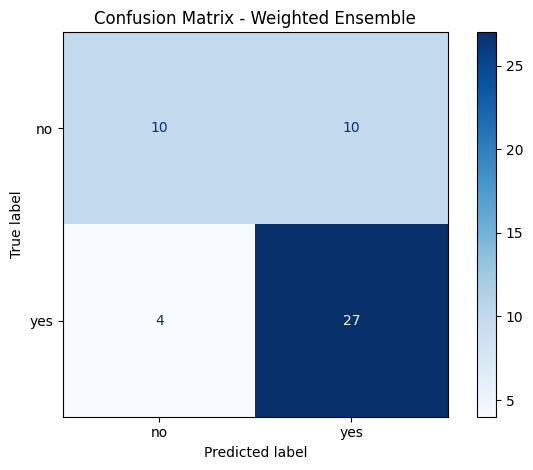

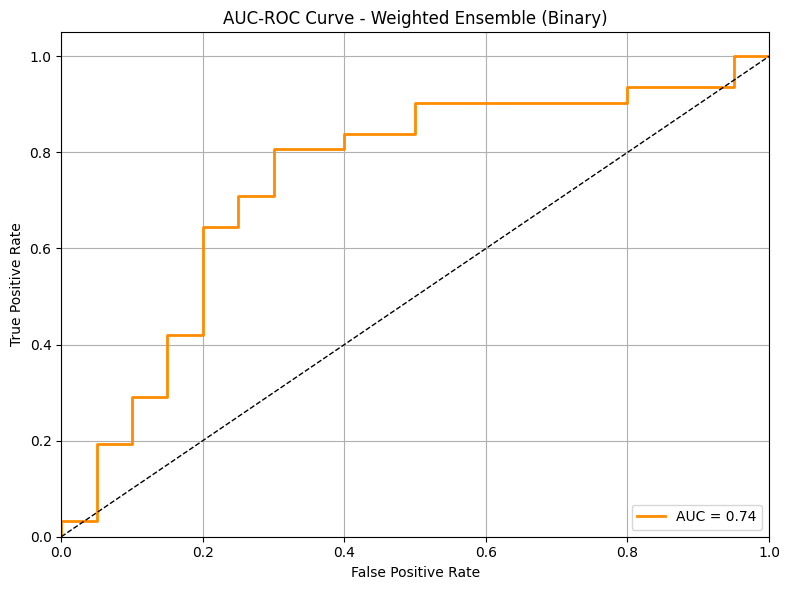

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, \
    log_loss, mean_absolute_error, mean_squared_error, cohen_kappa_score, hamming_loss, \
    roc_curve, auc, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# === Final Prediction using Best Weights ===
weighted_pred = sum(w * p for w, p in zip(
    [best['w_cnn'], best['w_alex'], best['w_vgg'], best['w_gan']],
    [pred_cnn, pred_alex, pred_vgg, pred_gan]
))
weighted_pred_labels = np.argmax(weighted_pred, axis=1)

# === Weighted Ensemble Accuracy ===
acc_ensemble = accuracy_score(y_true, weighted_pred_labels)
print("\n==============================")
print(" FINAL WEIGHTED ENSEMBLE PERFORMANCE")
print("==============================")
print(f"\nWeighted Ensemble Accuracy: {acc_ensemble:.4f}")

# === Classification Report ===
print("\n📋 Classification Report:")
print(classification_report(y_true, weighted_pred_labels, target_names=le.classes_))

# === Confusion Matrix ===
cm = confusion_matrix(y_true, weighted_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Weighted Ensemble")
plt.tight_layout()
plt.show()

# === AUC-ROC Curve (For Binary Classification Only) ===
if len(le.classes_) == 2:
    y_score_binary = weighted_pred[:, 1]  # Probability of positive class
    fpr, tpr, _ = roc_curve(y_true, y_score_binary)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUC-ROC Curve - Weighted Ensemble (Binary)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [19]:
# ============================
# 📉 LOSS FUNCTION EVALUATION (for Optimal Weights)
# ============================
from sklearn.metrics import (
    log_loss, mean_absolute_error,
    mean_squared_error, cohen_kappa_score, hamming_loss
)

# Use the weighted predictions you already computed during grid search
# (Make sure 'weighted_preds' and 'y_pred' or 'weighted_pred_labels' are already available)

# === Compute Loss Metrics ===
logloss = log_loss(y_true, weighted_preds)
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
h_loss = hamming_loss(y_true, y_pred)

# === Display Results ===
print("\n==============================")
print("📉 LOSS FUNCTION METRICS (Optimal Weights)")
print("==============================")
print(f"🔻 Log Loss (Cross-Entropy): {logloss:.4f}")
print(f"🔸 Mean Absolute Error: {mae:.4f}")
print(f"🔹 Mean Squared Error: {mse:.4f}")
print(f"📘 Cohen's Kappa Score: {kappa:.4f}")
print(f"📕 Hamming Loss: {h_loss:.4f}")



📉 LOSS FUNCTION METRICS (Optimal Weights)
🔻 Log Loss (Cross-Entropy): 0.6099
🔸 Mean Absolute Error: 0.3529
🔹 Mean Squared Error: 0.3529
📘 Cohen's Kappa Score: 0.1715
📕 Hamming Loss: 0.3529


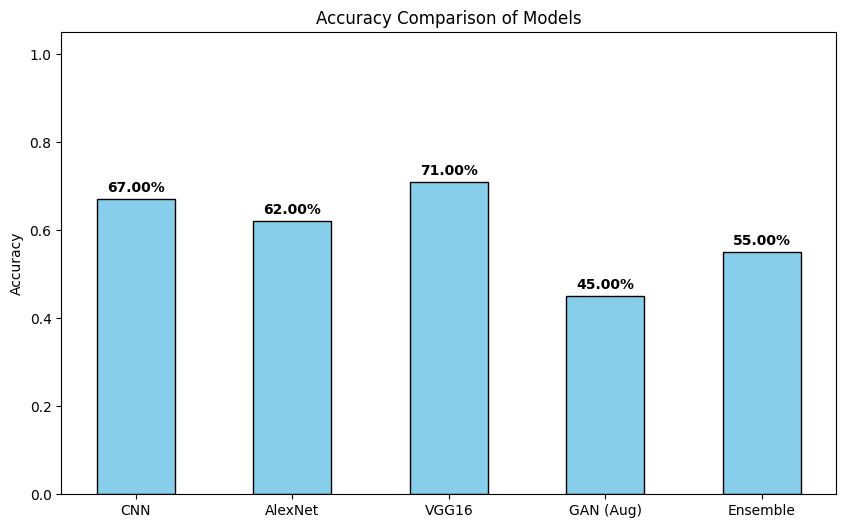

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Actual accuracies
models = ["CNN", "AlexNet", "VGG16", "GAN (Aug)", "Ensemble"]
accuracy = [0.67, 0.62, 0.71, 0.45, 0.55]

x = np.arange(len(models))
width = 0.5

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(x, accuracy, width, color="skyblue", edgecolor="black")

ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison of Models')
ax.set_xticks(x)
ax.set_xticklabels(models)

# Add accuracy values above each bar (percentage format)
for bar, acc in zip(bars, accuracy):
    height = bar.get_height()
    ax.annotate(f'{acc*100:.2f}%',   # convert to %
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.ylim(0, 1.05)  # scale up to 100% = 1.0
plt.show()


In [21]:
# === Other Metrics ===
print(f"📌 Log Loss: {log_loss(y_test, weighted_pred):.4f}")
print(f"📌 Mean Absolute Error (MAE): {mean_absolute_error(y_true, weighted_pred_labels):.4f}")
print(f"📌 Mean Squared Error (MSE): {mean_squared_error(y_true, weighted_pred_labels):.4f}")
print(f"📌 Cohen's Kappa Score: {cohen_kappa_score(y_true, weighted_pred_labels):.4f}")
print(f"📌 Hamming Loss: {hamming_loss(y_true, weighted_pred_labels):.4f}")

📌 Log Loss: 0.6256
📌 Mean Absolute Error (MAE): 0.2745
📌 Mean Squared Error (MSE): 0.2745
📌 Cohen's Kappa Score: 0.3918
📌 Hamming Loss: 0.2745
